In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
import wandb

wandb.login(key="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")

wandb.init(
    project="24f3004935-t22026"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 24f3004935 (24f3004935-dl-genai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
Train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

print(Train.shape)
print(test.shape)

Train.head()

(2000, 8)
(500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [5]:
label2id = {
    "A":0,
    "B":1,
    "C":2,
    "D":3,
    "E":4
}

id2label = {v:k for k,v in label2id.items()}

Train["label"] = Train["answer"].map(label2id)

In [6]:
Train_cleaned = Train.drop_duplicates(subset=["prompt"]).copy()

In [7]:
Train = Train_cleaned.sample(frac=1.0, random_state=42).reset_index(drop=True)

In [8]:
# Train["text"] = (
#     "Question: " + Train["prompt"].fillna("") +
#     " A: " + Train["A"].fillna("") +
#     " B: " + Train["B"].fillna("") +
#     " C: " + Train["C"].fillna("") +
#     " D: " + Train["D"].fillna("") +
#     " E: " + Train["E"].fillna("")
# )

# test["text"] = (
#     "Question: " + test["prompt"].fillna("") +
#     " A: " + test["A"].fillna("") +
#     " B: " + test["B"].fillna("") +
#     " C: " + test["C"].fillna("") +
#     " D: " + test["D"].fillna("") +
#     " E: " + test["E"].fillna("")
# )

### Train-Test split

In [9]:
from sklearn.model_selection import train_test_split

train, val = train_test_split(
    Train,
    test_size=0.2,
    random_state=42,
    stratify=Train["answer"]
)

In [10]:
Train.head(2)

,id,prompt,A,B,C,D,E,answer,label
0,1233,Identify the correct statement: What is the se...,The second law of thermodynamics is a physical...,The second law of thermodynamics is a physical...,The second law of thermodynamics is a physical...,The second law of thermodynamics is a physical...,The second law of thermodynamics is a physical...,E,4
1,1118,Pick the best possible answer: What is the sig...,The high degree of fatty-acyl disorder in the ...,The high degree of fatty-acyl disorder in the ...,The high degree of fatty-acyl disorder in the ...,The high degree of fatty-acyl disorder in the ...,The high degree of fatty-acyl disorder in the ...,C,2


In [11]:
val.head(2)

,id,prompt,A,B,C,D,E,answer,label
549,180,What is the Kutta condition?,The Kutta condition is a physical requirement ...,The Kutta condition is a physical requirement ...,The Kutta condition is a mathematical requirem...,The Kutta condition is a mathematical requirem...,The Kutta condition is a physical requirement ...,A,0
1054,414,Which of the following is correct? What is the...,The complete electromagnetic Hamiltonian of an...,The complete electromagnetic Hamiltonian of an...,The complete electromagnetic Hamiltonian of an...,The complete electromagnetic Hamiltonian of an...,The complete electromagnetic Hamiltonian of an...,D,3


## SCRATCH

In [12]:
import re
import math
import random
from collections import Counter

import wandb

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score

### Building Vocabulary

In [ ]:
# Building the vocabulary from training data
counter = Counter()

for text in Train["text"]:
    words = re.findall(r"\b\w+\b", text.lower())
    counter.update(words)

# Special tokens
vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

# Adding the words to vocabulary
for word, _ in counter.items():
    vocab[word] = len(vocab) # dict

# Reverse lookup 
id2word = {idx: word for word, idx in vocab.items()}

print("Vocabulary Size:", len(vocab))
print(list(vocab.items())[:15])

In [ ]:
MAX_LEN = 256

def encode_text(text):
    # Tokenization
    words = re.findall(r"\b\w+\b", text.lower())

    # Converting words to ids
    ids = [
        vocab.get(word, vocab["<UNK>"])
        for word in words
    ]

    # Truncate
    ids = ids[:MAX_LEN]

    # Padding
    padding = [vocab["<PAD>"]] * (MAX_LEN - len(ids))
    ids = ids + padding

    return ids

In [ ]:
sample = encode_text(Train["text"].iloc[0])

print(sample[:30])
print(len(sample))

### Pytorch Dataset

In [ ]:
class MCQDataset(Dataset):

    def __init__(self, dataframe, is_test=False):
        self.data = dataframe
        self.is_test = is_test

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        text = self.data.iloc[idx]["text"]

        input_ids = torch.tensor(
            encode_text(text),
            dtype=torch.long
        )

        # Attention mask
        attention_mask = (input_ids != vocab["<PAD>"]).long()

        if self.is_test:
            return {
                "input_ids": input_ids,
                "attention_mask": attention_mask
            }

        label = torch.tensor(
            self.data.iloc[idx]["label"],
            dtype=torch.long
        )

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": label
        }

In [ ]:
train_dataset = MCQDataset(train)

val_dataset = MCQDataset(val)

test_dataset = MCQDataset(test,is_test=True)

sample = train_dataset[0]

print(sample.keys())
print(sample["input_ids"].shape)
print(sample["attention_mask"].shape)
print(sample["labels"])

### Dataloader

In [ ]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    generator=torch.Generator().manual_seed(SEED)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

## Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=256):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [ ]:
pos = PositionalEncoding(d_model=128)

x = torch.zeros(2, 256, 128)

y = pos(x)

print(y.shape)

### Transformer Classifier

In [ ]:
class TransformerClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        num_heads=4,
        num_layers=2,
        hidden_dim=256,
        num_classes=5,
        dropout=0.2
    ):
        super().__init__()

        # Word Embeddings
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        # Positional Encoding
        self.pos_encoder = PositionalEncoding(embed_dim)

        # One Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )

        # Stack Multiple Encoder Layers
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )


        # Forward 

    def forward(self, input_ids, attention_mask):
    
        # Word Embeddings
        x = self.embedding(input_ids)
    
        # Add Positional Encoding
        x = self.pos_encoder(x)
    
        # Transformer Encoder
        x = self.transformer(
            x,
            src_key_padding_mask=(attention_mask == 0)
        )
    
        # Masked Mean Pooling
        mask = attention_mask.unsqueeze(-1)
    
        x = x * mask
    
        x = x.sum(dim=1)
    
        lengths = mask.sum(dim=1).clamp(min=1)
    
        x = x / lengths
    
        # Dropout
        x = self.dropout(x)
    
        # Classification
        logits = self.classifier(x)
    
        return logits

In [ ]:
model = TransformerClassifier(
    vocab_size=len(vocab)
)

batch = next(iter(train_loader))

logits = model(
    batch["input_ids"],
    batch["attention_mask"]
)

print(logits.shape)

### Training

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=0.01
)

In [ ]:
EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ---------------- Evaluation ----------------
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    model.train()

    # ---------------- WandB ----------------
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "val_accuracy": acc,
        "val_f1_score": f1,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Accuracy: {acc:.4f} | "
        f"F1: {f1:.4f}"
    )

wandb.finish()

### Testing

In [ ]:
model = TransformerClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    num_heads=4,
    hidden_dim=256,
    num_layers=2,
    num_classes=5
)

model.to(device)

In [ ]:
model.eval()

predictions = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ) 

        probs = torch.softmax(logits, dim=1)

        top3 = torch.argsort(
            probs,
            dim=1,
            descending=True
        )[:, :3]

        predictions.extend(top3.cpu().numpy())

In [ ]:
final_predictions = []

for pred in predictions:
    labels = [id2label[i] for i in pred]
    final_predictions.append(" ".join(labels))

## PRE-TRAINED MODEL

In [13]:
from transformers import AutoTokenizer

MODEL = "allenai/scibert_scivocab_uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL)

In [15]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    # 1. Predictions for Accuracy and F1 (Top 1)
    preds = logits.argmax(axis=-1)
    
    # 2. Top 3 Predictions for MAP@3
    top_3_preds = np.argsort(-logits, axis=-1)[:, :3] 
    
    # 3. Calculate MAP@3 manually
    map_at_3_scores = []
    for label, top_3 in zip(labels, top_3_preds):
        score = 0.0
        for rank, pred in enumerate(top_3):
            if pred == label:
                score = 1.0 / (rank + 1)
                break
        map_at_3_scores.append(score)
        
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "map_at_3": np.mean(map_at_3_scores)
    }


In [16]:
def tokenize_mc(examples):
    # For each row, create 5 (question, option) pairs
    # AutoModelForMultipleChoice expects shape [batch, num_choices, seq_len]
    
    questions = [[q] * 5 for q in examples["prompt"]]  # repeat question 5x per row
    options = [
        [a, b, c, d, e]
        for a, b, c, d, e in zip(
            examples["A"], examples["B"], examples["C"],
            examples["D"], examples["E"]
        )
    ]
    
    # Flatten for tokenizer: [q1,q1,q1,q1,q1, q2,q2,...] and [A1,B1,C1,D1,E1, A2,...]
    flat_questions = sum(questions, [])
    flat_options = sum(options, [])
    
    tokenized = tokenizer(
        flat_questions,
        flat_options,
        truncation=True,
        padding="max_length",
        max_length=512
    )
    
    # Reshape back to [batch, 5, seq_len]
    batch_size = len(examples["prompt"])
    result = {
        k: [v[i*5:(i+1)*5] for i in range(batch_size)]
        for k, v in tokenized.items()
    }
    return result

In [18]:
from datasets import Dataset
# Keep label column as-is (0-4 integers)
train_ds = Dataset.from_pandas(
    train[["prompt", "A", "B", "C", "D", "E", "label"]]
)
val_ds = Dataset.from_pandas(
    val[["prompt", "A", "B", "C", "D", "E", "label"]]
)
test_ds = Dataset.from_pandas(
    test[["prompt", "A", "B", "C", "D", "E"]]
)

train_ds = train_ds.map(tokenize_mc, batched=True, remove_columns=["prompt","A","B","C","D","E"])
val_ds = val_ds.map(tokenize_mc, batched=True, remove_columns=["prompt","A","B","C","D","E"])
test_ds = test_ds.map(tokenize_mc, batched=True, remove_columns=["prompt","A","B","C","D","E"])

Map:   0%|          | 0/1406 [00:00<?, ? examples/s]

Map:   0%|          | 0/352 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [20]:
from transformers import (
    AutoModelForMultipleChoice,
    Trainer,
    TrainingArguments
)

model_1 = AutoModelForMultipleChoice.from_pretrained(MODEL)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly init

In [21]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.05,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss", 
    greater_is_better=False,           
    save_strategy="epoch",
    eval_strategy="epoch",             
    save_total_limit=2,
    seed=42,
    data_seed=42,
    report_to="wandb"
)


In [22]:
# 1. Initialize the Trainer exactly as before
trainer = Trainer(
    model=model_1,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

# 2. Run the training loop (This automatically reloads the best model at the end)
trainer.train()

print("\nExtracting final model predictions...")
val_output = trainer.predict(val_ds)
val_results = val_output.metrics
val_preds = val_output.predictions.argmax(axis=-1)
val_labels = val_output.label_ids

# Subset of 1000 rows for the training confusion matrix
train_sample = train_ds.select(range(min(1000, len(train_ds))))
train_output = trainer.predict(train_sample)
train_results = train_output.metrics
train_preds = train_output.predictions.argmax(axis=-1)
train_labels = train_output.label_ids

# Print clear side-by-side performance summary table
print("\n" + "="*50)
print("          FINAL MODEL PERFORMANCE COMPARISON          ")
print("="*50)
print(f"TRAIN MAP@3:      {train_results.get('test_map_at_3', 0.0):.4f}  |  VAL MAP@3:      {val_results.get('test_map_at_3', 0.0):.4f}")
print(f"TRAIN Accuracy:   {train_results.get('test_accuracy', 0.0):.4f}  |  VAL Accuracy:   {val_results.get('test_accuracy', 0.0):.4f}")
print(f"TRAIN F1 Macro:   {train_results.get('test_f1_macro', 0.0):.4f}  |  VAL F1 Macro:   {val_results.get('test_f1_macro', 0.0):.4f}")
print("="*50)

# Save the final submission artifacts cleanly
trainer.save_model("./best_submission_model")
tokenizer.save_pretrained("./best_submission_model")
print("\nArtifacts locked down in folder: './best_submission_model'\n")


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Map At 3
1,3.022788,1.632660,0.769886,0.764148,0.840909
2,1.430164,0.844620,0.892045,0.891420,0.926610
3,0.792148,0.578012,0.920455,0.918976,0.942708
4,0.661660,0.515552,0.931818,0.930798,0.960701


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Extracting final model predictions...



          FINAL MODEL PERFORMANCE COMPARISON          
TRAIN MAP@3:      0.9683  |  VAL MAP@3:      0.9607
TRAIN Accuracy:   0.9440  |  VAL Accuracy:   0.9318
TRAIN F1 Macro:   0.9443  |  VAL F1 Macro:   0.9308


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Artifacts locked down in folder: './best_submission_model'



## CONFUSION MATRIX

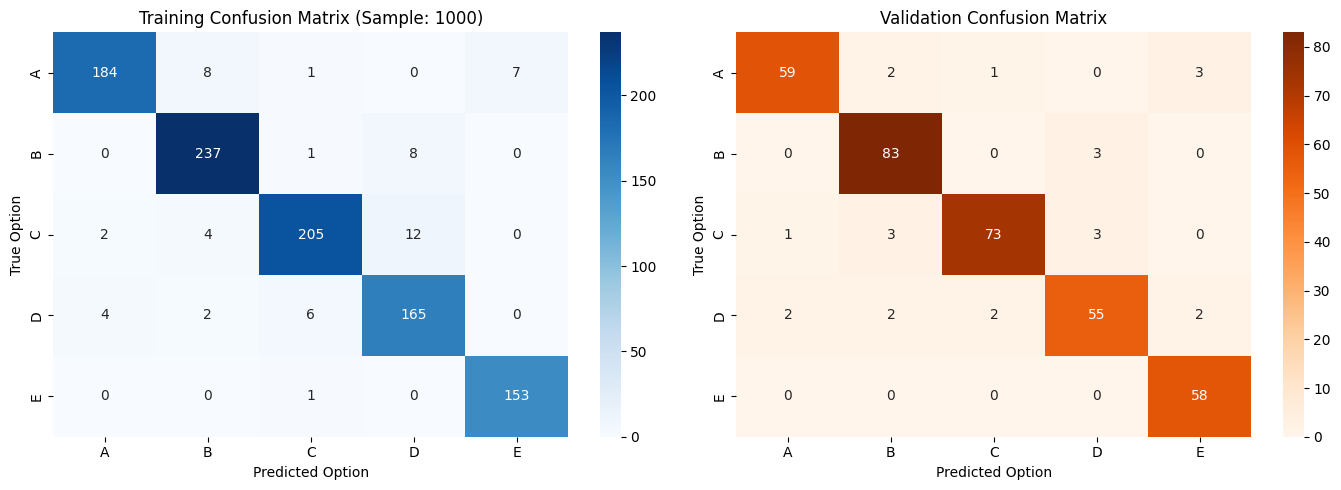

In [23]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_train = confusion_matrix(train_labels, train_preds)
cm_val = confusion_matrix(val_labels, val_preds)
class_names = ['A', 'B', 'C', 'D', 'E']

# Create subplots (axes becomes an array of length 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Train -> Target the first subplot with axes[0]
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Training Confusion Matrix (Sample: {len(train_sample)})')
axes[0].set_xlabel('Predicted Option')
axes[0].set_ylabel('True Option')

# Plot Validation -> Target the second subplot with axes[1]
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Option')
axes[1].set_ylabel('True Option')

plt.tight_layout()
plt.show()


## TOP 3 PREDICTIONS

In [24]:
import numpy as np
import torch

pred = trainer.predict(test_ds)

probs = torch.softmax(
    torch.tensor(pred.predictions),
    dim=1
).numpy()

pretrained_predictions = []

for p in probs:
    top3 = np.argsort(p)[::-1][:3]
    pretrained_predictions.append(
        " ".join(id2label[i] for i in top3)
    )

# MILESTONE 1

In [ ]:
# print(train['answer'].value_counts(ascending=False))
# freq_dist = list(train['answer'].value_counts(ascending=False))
# print(freq_dist[0]+freq_dist[-1])

In [ ]:
# import string

# vocab = set()

# for text in train["prompt"]:
#     # lowercase
#     text = str(text).lower()

#     # remove standard punctuation
#     text = text.translate(
#         str.maketrans('', '', string.punctuation)
#     )

#     # split by whitespace
#     words = text.split()

#     vocab.update(words)

# print("Vocabulary Size:", len(vocab))

In [ ]:
# from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
# # Row ID 1
# text = train.loc[train["id"] == 1, "prompt"].iloc[0]

# # lowercase + remove punctuation
# text = text.lower()
# text = text.translate(str.maketrans('', '', string.punctuation))

# # tokenize
# words = text.split()

# # remove stopwords
# filtered_words = [w for w in words if w not in ENGLISH_STOP_WORDS]

# print(filtered_words)
# print("Count:", len(filtered_words))

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# combined_text = (
#     train["prompt"].fillna("") + " " +
#     train["A"].fillna("") + " " +
#     train["B"].fillna("") + " " +
#     train["C"].fillna("") + " " +
#     train["D"].fillna("") + " " +
#     train["E"].fillna("")
# )

# vectorizer = TfidfVectorizer(stop_words="english")

# X = vectorizer.fit_transform(combined_text)

# print("Vocabulary Size:", len(vectorizer.get_feature_names_out()))

In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity

# row = train.iloc[0]   # Row ID 1 if first row

# prompt_vec = vectorizer.transform([row["prompt"]])
# A_vec = vectorizer.transform([row["A"]])

# score = cosine_similarity(prompt_vec, A_vec)[0][0]

# print(round(score, 4))

In [ ]:
# correct = 0

# for _, row in train.iterrows():

#     prompt_vec = vectorizer.transform([row["prompt"]])

#     scores = {}

#     for option in ["A", "B", "C", "D", "E"]:

#         option_vec = vectorizer.transform([row[option]])

#         scores[option] = cosine_similarity(
#             prompt_vec,
#             option_vec
#         )[0][0]

#     predicted = max(scores, key=scores.get) # highest cosine similarity

#     if predicted == row["answer"]:
#         correct += 1

# accuracy = (correct / len(train)) * 100

# print(f"Accuracy: {accuracy:.2f}%")

In [ ]:
# def map_at_3(actual, predicted):
#     try:
#         rank = predicted.index(actual) + 1
#         return 1.0 / rank
#     except ValueError:
#         return 0.0

# actual = "C"
# predicted = ["C", "A", "B"]

# score = map_at_3(actual, predicted)

# print(score)

In [ ]:
# actual = "B"
# predicted = ["D", "B", "E"]

# score = map_at_3(actual, predicted)

# print(score)

In [ ]:
# top3 = train["answer"].value_counts().index[:3].tolist()

# prediction = top3

# score = 0

# for ans in train["answer"]:

#     if ans == prediction[0]:
#         score += 1.0

#     elif ans == prediction[1]:
#         score += 0.5

#     elif ans == prediction[2]:
#         score += 1/3

# map3 = score / len(train)

# print("Top 3:", prediction)
# print("MAP@3:", round(map3, 4))

# MILESTONE 2

## Preprocessing

In [ ]:
# from datasets import load_dataset

# # Load train.csv
# Train = load_dataset(
#     "csv",
#     data_files="/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
# )["train"]

# # Create combined_text = prompt + " " + A
# Train = Train.map(
#     lambda x: {
#         "combined_text": x["prompt"] + " " + x["A"]
#     }
# )

# # Character length of row 51
# print(len(Train[51]["combined_text"]))

In [ ]:
# from transformers import AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# print(tokenizer.vocab_size)

In [ ]:
# from transformers import AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# print(tokenizer.sep_token)
# # print(tokenizer.sep_token_id)

In [ ]:
# print(Train)
# print(type(Train))

In [ ]:
# print(type(Train["prompt"]))
# print(type(Train["prompt"][0]))
# print(Train["prompt"][0])

In [ ]:
# encodings = tokenizer(
#     list(Train["prompt"]),
#     padding="max_length",
#     truncation=True,
#     max_length=128,
#     return_tensors="pt"
# )

# print(encodings["input_ids"].shape)

In [ ]:
# from transformers import AutoConfig

# config = AutoConfig.from_pretrained("bert-base-uncased")

# hidden_size = config.hidden_size
# num_heads = config.num_attention_heads

# head_dim = hidden_size // num_heads

# print("Hidden Size:", hidden_size)
# print("Attention Heads:", num_heads)
# print("Head Dimension:", head_dim)

In [ ]:
# from datasets import load_dataset
# from transformers import AutoTokenizer, AutoModel

# # Load tokenizer and model
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# model = AutoModel.from_pretrained("bert-base-uncased")

# # Tokenize row 0 prompt (default settings)
# inputs = tokenizer(Train[0]["prompt"], return_tensors="pt")

# # Forward pass
# outputs = model(**inputs)

# # Print shape
# print(outputs.last_hidden_state.shape)

In [ ]:
# # Extract CLS embedding (batch 0, token 0)
# cls_embedding = outputs.last_hidden_state[0, 0]

# # Sum first 5 values
# answer = cls_embedding[:5].sum().item()

# print(round(answer, 4))

In [ ]:
# model = AutoModel.from_pretrained(
#     "bert-base-uncased",
#     output_attentions=True
# )

# inputs = tokenizer("Light-ion fusion is a technique.", return_tensors="pt")
# outputs = model(**inputs)

# tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
# fusion_index = tokens.index("fusion")

# attention = outputs.attentions[-1][0, 0]

# print(round(attention[0, fusion_index].item(), 4))

In [ ]:
# from sentence_transformers import SentenceTransformer, util

# model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# # Get prompt and Option B from row 0
# prompt = Train[0]["prompt"]
# option_b = Train[0]["B"]

# # Generate embeddings
# prompt_embedding = model.encode(prompt, convert_to_tensor=True)
# option_b_embedding = model.encode(option_b, convert_to_tensor=True)

# # Cosine similarity
# similarity = util.cos_sim(prompt_embedding, option_b_embedding)

# print(round(similarity.item(), 4))

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# mini_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# options = ["A", "B", "C", "D", "E"]

# mini_map = 0
# improved = 0

# for row in Train:

#     prompt = row["prompt"]
#     answer = row["answer"]

#     # Pipeline 1 : TF-IDF

#     docs = [prompt] + [row[o] for o in options]

#     tfidf = TfidfVectorizer()
#     X = tfidf.fit_transform(docs)

#     sims = cosine_similarity(X[0], X[1:]).flatten()

#     tfidf_rank = [
#         options[i]
#         for i in sims.argsort()[::-1]
#     ]


#     # Pipeline 2 : MiniLM

#     prompt_emb = mini_model.encode(prompt, convert_to_tensor=True)
#     option_embs = mini_model.encode(
#         [row[o] for o in options],
#         convert_to_tensor=True
#     )

#     sims = util.cos_sim(prompt_emb, option_embs)[0].cpu().numpy()

#     mini_rank = [
#         options[i]
#         for i in sims.argsort()[::-1]
#     ]

#     # MAP@3
#     top3 = mini_rank[:3]

#     if answer in top3:
#         mini_map += 1 / (top3.index(answer) + 1)


#     # Improvement count
#     tfidf_hit = answer in tfidf_rank[:3]
#     mini_hit = answer in mini_rank[:3]

#     if (not tfidf_hit) and mini_hit:
#         improved += 1

# mini_map /= len(Train)

# print("MiniLM MAP@3:", round(mini_map, 4))
# print("Improved count:", improved)

In [ ]:
# from transformers import pipeline
# # Initialize zero-shot classifier
# classifier = pipeline("zero-shot-classification")

# # Prompt from row index 1
# prompt = Train[1]["prompt"]

# # Candidate labels: Options A, B, C
# candidate_labels = [
#     Train[1]["A"],
#     Train[1]["B"],
#     Train[1]["C"]
# ]

# # Predict
# result = classifier(
#     prompt,
#     candidate_labels=candidate_labels
# )

# # Probability score of the top-ranked option
# print(round(result["scores"][0], 4))

In [ ]:
# result_softmax = classifier(
#     prompt,
#     candidate_labels=candidate_labels
# )

# # This question (Independent Sigmoids)
# result_sigmoid = classifier(
#     prompt,
#     candidate_labels=candidate_labels,
#     multi_label=True
# )

# softmax_sum = sum(result_softmax["scores"])
# sigmoid_sum = sum(result_sigmoid["scores"])

# print("Softmax sum:", softmax_sum)
# print("Sigmoid sum:", sigmoid_sum)
# print("Absolute difference:", round(abs(softmax_sum - sigmoid_sum), 4))

In [ ]:
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
# model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

# text = (
#     f"Question: {Train[0]['prompt']}. "
#     f"Is the correct answer A: {Train[0]['A']} "
#     f"or B: {Train[0]['B']}? "
#     f"Answer with just the letter A or B."
# )

# inputs = tokenizer(text, return_tensors="pt")

# outputs = model.generate(
#     **inputs,
#     max_new_tokens=5
# )

# print(tokenizer.decode(outputs[0], skip_special_tokens=True))

# MILESTONE 3

In [ ]:
# !pip install faiss-cpu #install FAISS

# import pandas as pd 
# import numpy as np 
# import faiss 
# from sentence_transformers import SentenceTransformer, CrossEncoder 
# from transformers import AutoTokenizer, pipeline 
# from sklearn.feature_extraction.text import TfidfVectorizer 
# from sklearn.metrics.pairwise import cosine_similarity 

# train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv') 

# print("Creating knowledge base")
# kb = [] 
# for idx, row in train.iterrows(): 
#     correct_letter = row['answer'] 
#     kb.append(str(row[correct_letter])) 

# print("Loading embedding model and creating index") 
# model = SentenceTransformer('all-MiniLM-L6-v2') 
# kb_embeddings = model.encode(kb, show_progress_bar=False) 
# index = faiss.IndexFlatL2(kb_embeddings.shape[1]) 
# index.add(kb_embeddings)

# print("Knowledge base successfully created")

In [ ]:
# zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli") 
# row_150 = train.iloc[150] 
# prompt_150 = str(row_150['prompt']) 
# labels_150 = [str(row_150['A']), str(row_150['B']), str(row_150['C']), str(row_150['D']), str(row_150['E'])] 
# ans_150 = str(row_150[row_150['answer']])

In [ ]:
# result = zs(prompt_150 , candidate_labels = labels_150)

# for label , score in zip(result['labels'] , result['scores']):
#     print(label , round(score,3))

# correct_score = result['scores'][result['labels'].index(ans_150)]

# print("\nCorrect Answer:", ans_150)
# print("Probability:", round(correct_score,3))

In [ ]:
# # Row 150 prompt
# query = train.iloc[150]["prompt"]

# # Embed the prompt
# query_embedding = model.encode([query])

# # Retrieve Top-10
# distances, indices = index.search(query_embedding, k=10)

# print("Retrieved indices:", indices[0])

# # Find the rank of the correct document (KB index = 150)
# if 150 in indices[0]:
#     rank = list(indices[0]).index(150) + 1
#     print("Rank of correct document:", rank)
# else:
#     print("Correct document not found in Top-10")

In [ ]:
# from sentence_transformers import CrossEncoder
# import numpy as np

# # Load Cross-Encoder
# cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# # Top-10 document indices from FAISS
# retrieved_indices = indices[0]

# # Corresponding documents
# docs_10 = [kb[i] for i in retrieved_indices]

# # Create (question, document) pairs
# pairs = [[prompt_150, doc] for doc in docs_10]

# # Cross-Encoder scores
# ce_scores = cross_encoder.predict(pairs)

# # Sort by score (highest first)
# sorted_idx = np.argsort(ce_scores)[::-1]

# # Re-ranked document indices
# reranked_indices = retrieved_indices[sorted_idx]

# print("Re-ranked document indices:")
# print(reranked_indices)

# # Find rank of the correct document (KB index 150)
# if 150 in reranked_indices:
#     rank = list(reranked_indices).index(150) + 1
#     print("Rank of correct document:", rank)
# else:
#     print("Correct document not found in Top-10")

In [ ]:
# from transformers import AutoTokenizer

# # Load tokenizer
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# # Prompt from row 42
# prompt_42 = train.iloc[42]["prompt"]

# # Embed the prompt
# query_embedding = model.encode([prompt_42])

# # Retrieve Top-5 documents
# _, indices = index.search(query_embedding, k=5)

# # Concatenate documents
# retrieved_docs = [kb[i] for i in indices[0]]
# concatenated_docs = " ".join(retrieved_docs)

# # Create final input string
# text = f"Context: {concatenated_docs} Question: {prompt_42}"

# # Tokenize (NO truncation)
# tokens = tokenizer(text, truncation=False)

# # Total number of tokens
# print("Total tokens:", len(tokens["input_ids"]))

In [ ]:
# # Retrieve the TRUE document from KB
# true_document = kb[150]

# # Create RAG prompt
# rag_prompt = f"Context: {true_document} Question: {prompt_150}"

# # Zero-shot classification
# result = zs(rag_prompt, candidate_labels=labels_150)

# # Probability of the correct answer
# correct_score = result["scores"][result["labels"].index(ans_150)]

# print("Correct Answer:", ans_150)
# print("Probability:", round(correct_score, 3))

In [ ]:
# # Wrong (adversarial) document
# wrong_document = kb[999]

# # Create adversarial RAG prompt
# adversarial_prompt = f"Context: {wrong_document} Question: {prompt_150}"

# # Zero-shot classification
# result = zs(adversarial_prompt, candidate_labels=labels_150)

# # Probability of the correct answer
# correct_score = result["scores"][result["labels"].index(ans_150)]

# print("Correct Answer:", ans_150)
# print("Probability:", round(correct_score, 3))

In [ ]:
# hits = 0

# for i in range(100):

#     # Query
#     prompt = train.iloc[i]["prompt"]

#     # Correct answer text
#     correct_doc = str(train.iloc[i][train.iloc[i]["answer"]])

#     # Embed query
#     query_embedding = model.encode([prompt])

#     # Retrieve Top-5
#     _, indices = index.search(query_embedding, k=5)

#     # Retrieved documents
#     retrieved_docs = [kb[j] for j in indices[0]]

#     # Check if correct answer is present
#     if any(correct_doc in doc for doc in retrieved_docs):
#         hits += 1

# # Hit Rate
# hit_rate = (hits / 100) * 100

# print("Hits:", hits)
# print("Hit Rate:", round(hit_rate, 1))
# print(round(hit_rate, 1))

In [ ]:
# import numpy as np

# map3_scores = []

# for i in range(20):

#     # Query
#     prompt = str(train.iloc[i]["prompt"])

#     # Retrieve
#     query_embedding = model.encode([prompt])
#     _, indices = index.search(query_embedding, k=5)

#     retrieved_docs = [kb[j] for j in indices[0]]

#     # Rerank
#     pairs = [[prompt, doc] for doc in retrieved_docs]
#     ce_scores = cross_encoder.predict(pairs)

#     best_doc = retrieved_docs[np.argmax(ce_scores)]

#     # Augment
#     rag_prompt = f"Context: {best_doc} Question: {prompt}"

#     # Candidate Labels
#     candidate_labels = [
#         str(train.iloc[i]["A"]),
#         str(train.iloc[i]["B"]),
#         str(train.iloc[i]["C"]),
#         str(train.iloc[i]["D"]),
#         str(train.iloc[i]["E"])
#     ]

#     # Predict
#     result = zs(rag_prompt, candidate_labels=candidate_labels)

#     # Top-3 predicted option texts
#     top3_text = result["labels"][:3]

#     # Convert texts back to letters
#     text_to_letter = {
#         str(train.iloc[i]["A"]): "A",
#         str(train.iloc[i]["B"]): "B",
#         str(train.iloc[i]["C"]): "C",
#         str(train.iloc[i]["D"]): "D",
#         str(train.iloc[i]["E"]): "E",
#     }

#     top3_letters = [text_to_letter[t] for t in top3_text]

#     # MAP@3 
#     true_answer = train.iloc[i]["answer"]

#     if true_answer == top3_letters[0]:
#         score = 1.0
#     elif true_answer == top3_letters[1]:
#         score = 1/2
#     elif true_answer == top3_letters[2]:
#         score = 1/3
#     else:
#         score = 0.0

#     map3_scores.append(score)

# # Final MAP@3
# final_map3 = np.mean(map3_scores)

# print("MAP@3:", round(final_map3, 3))

# print(round(final_map3, 3))

# SUBMISSION

In [ ]:
# submission = pd.DataFrame({
#     "id": test["id"],
#     "Prediction": final_predictions
# })

# submission.to_csv("submission.csv", index=False)

# submission.head()

In [26]:
submission = pd.DataFrame({
    "id": test["id"],
    "Prediction": pretrained_predictions
})

submission.to_csv("submission.csv",index=False)

submission.head()

,id,Prediction
0,1,A D C
1,2,B D A
2,3,B E D
3,4,E C D
4,5,C A D
